In [2]:
#date: 2025-04-23
#author: Junjie Yang
#generate plots for the demographic analysis
#import peak area
# !pip install statannotations
import pandas as pd
import seaborn as sns
import numpy as np
import os
import sys

from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

In [3]:
#==========2 demographic data processing
demogra_data = pd.read_csv("D:/UCSF_postdoc_topic/REVEAL_first_400/demographics_data/REVEAL_fmt.csv")
# Clean and classify demographic data
demogra_data['ga_weeks_mr'] = pd.to_numeric(demogra_data['ga_weeks_mr'], errors='coerce')
demogra_data['bmi_preprg_mr'] = pd.to_numeric(demogra_data['bmi_preprg_mr'], errors='coerce')
demogra_data['age_dlvry_mr'] = pd.to_numeric(demogra_data['age_dlvry_mr'], errors = 'coerce')

demogra_data['Terms'] = np.where(
    demogra_data['ga_weeks_mr'].isna(), 
    np.nan, 
    np.where(demogra_data['ga_weeks_mr'] < 37, 'preterm', 'full_term')
)

demogra_data['GDM_diag'] = demogra_data['gstdiab_mr'].map({
    "1, Yes": "GDM",
    "0, No": "Non-GDM",
    ".N, Not Noted in MR": np.nan,
    ".M, Missing": np.nan
})

demogra_data['Edu'] = demogra_data['edu_m_pre_cv'].map({
    "5, Graduate Degree": "Post_grad",
    "4, Bachelor's Degree": "College",
    "3, Some College or AA Degree": "College",
    "1, <High School": "Highschool/less",
    "2, HS Degree or GED": "Highschool/less",
    ".": np.nan,
    "": np.nan
})

demogra_data['Race'] = demogra_data['race_m_cv'].map({
    '1, White': 'White',
    '2, Black or African American': 'Black',
    '3, Asian': 'Asian',
    '4, Native Hawaiian or Other Pacific Islander': 'other',
    '5, American Indian or Alaska Native': 'other',
    '6, More than 1 race': 'other',
    '-8, Unknown, Not Reported or Other': 'other'
    # 'hispanic': 'Latina'
})

demogra_data['Race_hispanic'] = demogra_data['hispanic_m_cv'].map({
    '0, No': 'Non-Latina',
    '1, Yes': 'Latina',
    'M': np.nan
})

def make_race_ethnicity(row):

    hisp = row["Race_hispanic"]
    race = row["Race"]

    if pd.notna(hisp) and hisp == "Latina":
        return "Hispanic"

    if pd.notna(hisp) and hisp == "Non-Latina":

        if pd.isna(race):
            return np.nan

        if race == "White":
            return "Non-Hispanc White"

        if race == "Black":
            return "Non-Hispanc Black"

        if race == "Asian":
            return "Non-Hispanc Asian"

        if race == "Other":
            return "Non-Hispanc Other"

        return np.nan

    # If Hispanic status is missing, keep race-only category as fallback.
    # You may also choose to return np.nan here if you want stricter coding.
    if pd.isna(hisp) and pd.notna(race):
        return "Unknown ethnicity " + str(race)

    return np.nan

demogra_data["Race_ethnicity"] = demogra_data.apply(
    make_race_ethnicity,
    axis=1
)

# demogra_data['Nativity'] = demogra_data['usborn_m_cv'].map({
#     '1, US Born': 'US',
#     '0, Foreign Born': 'other',
#     '.': 'other'
# })

demogra_data['Smoke'] = demogra_data['smoke_cv'].map({
    '2, Former smoker': 'former-smoke',
    '1, Never smoked': 'non-smoke',
    '3, Current smoker': 'current-smoke',
    '.': np.nan
})

demogra_data['hypertension'] = demogra_data['htn_prg_mr'].map({
    '1, Yes': 'hypertension',
    '0, No': 'non-hypertension',
    '.M, Missing': np.nan,
    '.N, Not Noted in MR': np.nan
})

demogra_data['preclmps_mr'] = demogra_data['preclmps_mr'].map({
    '1, Yes': 'preclampsia',
    '0, No': 'non-preclampsia',
    '.M, Missing': np.nan,
    '.N, Not Noted in MR': np.nan
})

demogra_data['BMI'] = demogra_data['bmi_preprg_mr']

demogra_data['hospital_del'] = demogra_data['hosp_mr'].map({
    '1, SFGH': 'SFGH',
    '2, Mission Bay': 'MB',
    '3, Elsewhere': 'other',
    'M': np.nan,
    'N': np.nan
})


# Convert ppt_id to string and reorder columns
demogra_data['ppt_id'] = demogra_data['ppt_id'].astype(str)
# cols = ['ppt_id', 'Terms', 'GDM_diag', 'Edu','hypertension','preclmps_mr'] + [col for col in demogra_data.columns if col not in ['ppt_id', 'Terms', 'GDM_diag', 'Edu']]
cols = ['ppt_id', 'Terms', 'GDM_diag', 'Edu','hypertension','preclmps_mr','age_dlvry_mr','hospital_del','BMI','Race_ethnicity']
demogra_data = demogra_data[cols]

# Print dimensions
print(demogra_data[demogra_data['Terms'] == 'preterm'].shape)
print(demogra_data[demogra_data['Terms'] == 'full_term'].shape)

(65, 10)
(671, 10)


In [7]:
import tabulate
print(demogra_data.columns)
print(tabulate.tabulate(demogra_data.head(10), headers='keys',tablefmt='psql'))
#summarize the na/non na value of each demographic variables

summary_na = pd.DataFrame({
    'Non_NA': demogra_data.notna().sum(),
    'NA': demogra_data.isna().sum(),
    'Percent_NA': (demogra_data.isna().mean() * 100).round(2)
})

print(tabulate.tabulate(
    summary_na.reset_index(),
    headers=['Variable', 'Non_NA', 'NA', '% Missing'],
    tablefmt='psql'
))

Index(['ppt_id', 'Terms', 'GDM_diag', 'Edu', 'hypertension', 'preclmps_mr',
       'age_dlvry_mr', 'hospital_del', 'BMI', 'Race_ethnicity'],
      dtype='object')
+----+----------+-----------+------------+-----------------+------------------+-----------------+----------------+----------------+--------+-------------------+
|    |   ppt_id | Terms     | GDM_diag   | Edu             | hypertension     | preclmps_mr     |   age_dlvry_mr | hospital_del   |    BMI | Race_ethnicity    |
|----+----------+-----------+------------+-----------------+------------------+-----------------+----------------+----------------+--------+-------------------|
|  0 |      101 | full_term | nan        | College         | nan              | nan             |            nan | nan            | nan    | nan               |
|  1 |      103 | full_term | Non-GDM    | Highschool/less | non-hypertension | non-preclampsia |             30 | SFGH           |  32.57 | Hispanic          |
|  2 |      104 | full_term | na

In [ ]:
################################3.1 logestic regression based on the binary identification##########################
#import raw peak area after blank subtraction
QA_feat_tab = pd.read_csv(r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\8QACs_matched_target_blanksub_avg_peakarea_0521.csv")

#drop the first two row, which are metabolites
QA_feat_tab = QA_feat_tab.iloc[2:]
#make featuer id and make it as idnex
QA_feat_tab.index = QA_feat_tab['Average Mz'].astype(str) + "_" + QA_feat_tab['Average Rt(min)'].astype(str)
#only save sample columns
cols = [col for col in QA_feat_tab.columns if col.startswith('BH')]
QA_feat_tab = QA_feat_tab[cols]
QA_feat_tab = QA_feat_tab.apply(pd.to_numeric, errors = 'coerce')

# Rename sample columns with participant IDs
sample_name = pd.read_csv("D:/UCSF_postdoc_topic/REVEAL_first_400/demographics_data/REVEAL_sample_name_positive_with_participantID.csv")
sample_ids = sample_name['Participant_ID'].dropna().astype(int).unique()
sample_ids = sample_ids.astype(str).tolist()
QA_feat_tab.columns = sample_ids  
#set the index as column, the sample columns and participant IDs from the sample_name are correspondingly in the same sequence, so just replace the sample name with the ID list
QA_feat_tab['peak_id'] = QA_feat_tab.index

########### 3.1 make detection table as binary feature table########
#convert value to binary for detection = 0 / non detection = 1
PEAK_THRESHOLD = 1000  #threshold from the blank subtracted peak area
cols = [c for c in QA_feat_tab.columns if c != 'peak_id']  #make data frame numeric
QA_feat_tab[cols] = (QA_feat_tab[cols].fillna(0) >= PEAK_THRESHOLD).astype(int)
    #final long table before Statistical Testing ==========
# Reshape to long format
pos_long = QA_feat_tab.melt(id_vars='peak_id', var_name='ppt_id', value_name='peak_detection')
## THE FIX: Drop duplicate columns ---
demogra_data = demogra_data.loc[:, ~demogra_data.columns.duplicated()]
# # Now the merge will be perfectly clean
pos_long = pos_long.merge(demogra_data, on='ppt_id', how='left')
print(tabulate.tabulate(pos_long, headers='keys', tablefmt='psql'))
# results = []
pos_long.to_csv(r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\QA_long_format_demographic_binary_0527.csv")

Input long-format table shape: (2400, 13)
Unique participants: 400
Unique QAC features: 6

Participant x QAC binary matrix: (400, 6)

Participant metadata table: (400, 11)

Silhouette summary:
   k  silhouette_jaccard                                 cluster_sizes
0  2            0.558832                              {1: 138, 2: 262}
1  3            0.526978                       {1: 138, 2: 14, 3: 248}
2  4            0.570471                {1: 138, 2: 14, 3: 91, 4: 157}
3  5            0.588053         {1: 138, 2: 14, 3: 91, 4: 15, 5: 142}
4  6            0.620675  {1: 138, 2: 14, 3: 49, 4: 42, 5: 15, 6: 142}

Selected k: 6

Chemical Spearman correlation:
                  228.26863_11.255  284.33133_15.087  304.30072_12.536  \
228.26863_11.255          1.000000          0.347599          0.104037   
284.33133_15.087          0.347599          1.000000          0.466474   
304.30072_12.536          0.104037          0.466474          1.000000   
332.33112_14.269          0.240718    

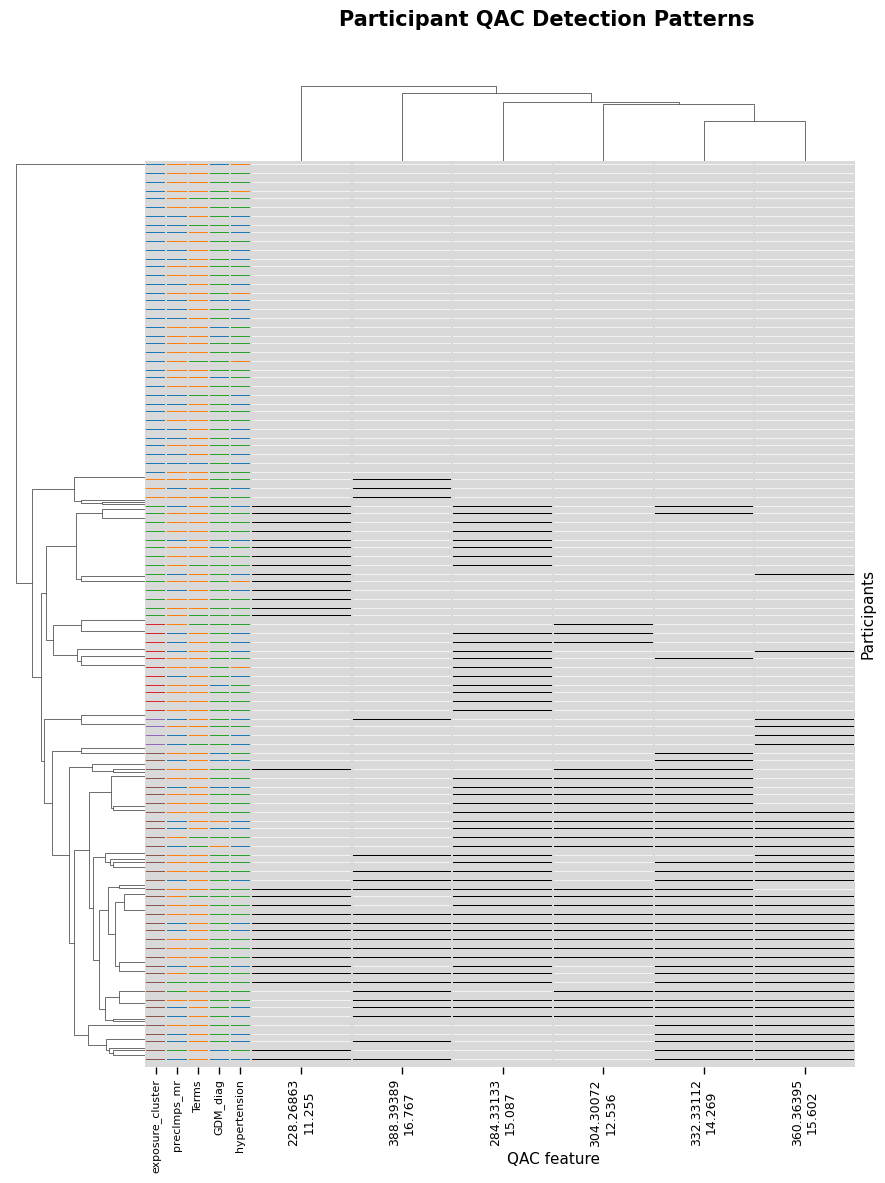

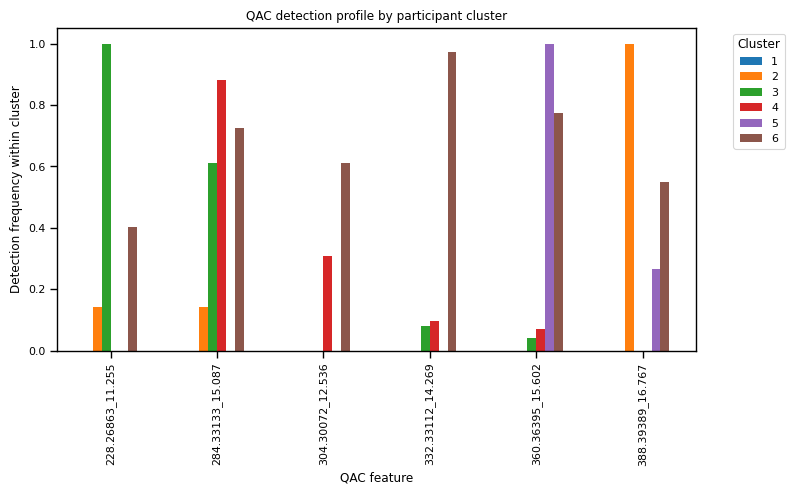

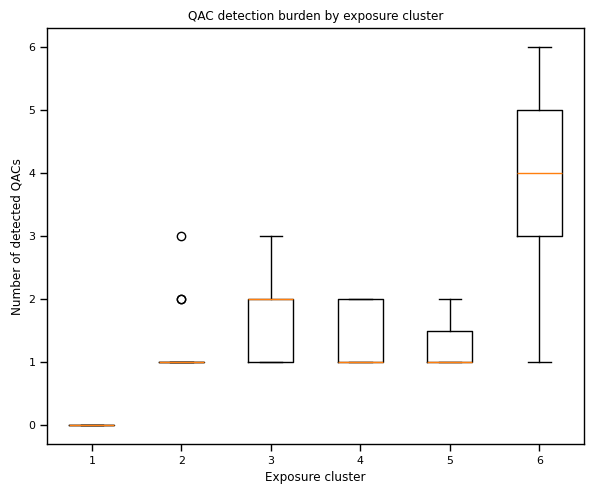

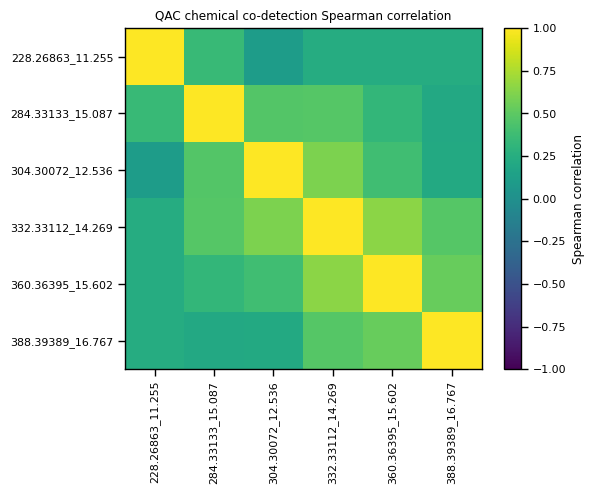


CLUSTERING ANALYSIS COMPLETE

Selected k: 6

Cluster sizes:
  exposure_cluster  n_participants
0                1             138
1                2              14
2                3              49
3                4              42
4                5              15
5                6             142

Cluster burden summary:
  exposure_cluster  count      mean  median  min  max
0                1    138  0.000000     0.0    0    0
1                2     14  1.285714     1.0    1    3
2                3     49  1.734694     2.0    1    3
3                4     42  1.357143     1.0    1    2
4                5     15  1.266667     1.0    1    2
5                6    142  4.035211     4.0    1    6

Top cluster-demographic/outcome associations:
              variable variable_type          method    n   statistic  \
9  qac_detection_count    continuous  Kruskal_Wallis  400  358.855763   
5       Race_ethnicity   categorical      Chi_square  373   35.874621   
4          preclmps_mr   

In [ ]:
# ============================================================
# QAC binary detection clustering analysis
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

from matplotlib.colors import ListedColormap
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.stats import chi2_contingency, fisher_exact, kruskal, spearmanr
from sklearn.metrics import silhouette_score
from statsmodels.stats.multitest import multipletests


# ============================================================
# User-editable parameters
# ============================================================

INPUT_PATH = r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\QA_long_format_demographic_0527.csv"
OUTPUT_DIR = r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\cluster_analysis_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

AUTO_SELECT_K = True
MANUAL_K = 6
K_RANGE = range(2, 7)
FDR_ALPHA = 0.10

categorical_vars = [
    "Terms",
    "GDM_diag",
    "Edu",
    "hypertension",
    "preclmps_mr",
    "Race_ethnicity",
    "Smoke",
    "hospital_del"
]

continuous_vars = [
    "age_dlvry_mr",
    "BMI",
    "qac_detection_count"
]

annotation_cols = [
    "exposure_cluster",
    "preclmps_mr",
    "Terms",
    "GDM_diag",
    "hypertension"
]


# ============================================================
# Helper functions
# ============================================================

def save_csv(df, filename, index=False):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=index)
    return path


def make_color_mapping(series, palette_name="tab10"):
    """
    Convert categorical labels into row annotation colors.
    Missing values are labeled as 'Missing'.
    """
    values = (
        series
        .astype("object")
        .where(series.notna(), "Missing")
        .astype(str)
    )

    unique_values = sorted(values.unique())

    palette = sns.color_palette(
        palette_name,
        n_colors=len(unique_values)
    )

    color_map = dict(zip(unique_values, palette))
    return values.map(color_map), color_map


def cluster_association_tests(meta, categorical_vars, continuous_vars):
    """
    Test whether exposure cluster membership is associated with
    demographic variables or pregnancy outcomes.

    Categorical variables:
        Fisher exact test for 2x2 tables
        Chi-square test for larger tables

    Continuous variables:
        Kruskal-Wallis test across clusters
    """
    rows = []

    categorical_vars = [c for c in categorical_vars if c in meta.columns]
    continuous_vars = [c for c in continuous_vars if c in meta.columns]

    for c in continuous_vars:
        meta[c] = pd.to_numeric(meta[c], errors="coerce")

    for var in categorical_vars:
        tmp = meta.dropna(subset=[var, "exposure_cluster"]).copy()

        if tmp[var].nunique() < 2 or tmp["exposure_cluster"].nunique() < 2:
            continue

        tab = pd.crosstab(tmp["exposure_cluster"], tmp[var])

        try:
            if tab.shape == (2, 2):
                stat, p_value = fisher_exact(tab.values)
                method = "Fisher_exact"
            else:
                stat, p_value, _, _ = chi2_contingency(tab)
                method = "Chi_square"

            rows.append({
                "variable": var,
                "variable_type": "categorical",
                "method": method,
                "n": tmp.shape[0],
                "statistic": stat,
                "p_value": p_value
            })

        except Exception as e:
            rows.append({
                "variable": var,
                "variable_type": "categorical",
                "method": "failed",
                "n": tmp.shape[0],
                "statistic": np.nan,
                "p_value": np.nan,
                "error": str(e)
            })

    for var in continuous_vars:
        tmp = meta.dropna(subset=[var, "exposure_cluster"]).copy()

        if tmp[var].nunique() < 2 or tmp["exposure_cluster"].nunique() < 2:
            continue

        groups = [
            g[var].dropna().values
            for _, g in tmp.groupby("exposure_cluster")
            if len(g[var].dropna()) > 0
        ]

        try:
            stat, p_value = kruskal(*groups)

            rows.append({
                "variable": var,
                "variable_type": "continuous",
                "method": "Kruskal_Wallis",
                "n": tmp.shape[0],
                "statistic": stat,
                "p_value": p_value
            })

        except Exception as e:
            rows.append({
                "variable": var,
                "variable_type": "continuous",
                "method": "failed",
                "n": tmp.shape[0],
                "statistic": np.nan,
                "p_value": np.nan,
                "error": str(e)
            })

    assoc_df = pd.DataFrame(rows)

    if not assoc_df.empty:
        valid = assoc_df["p_value"].notna()

        assoc_df.loc[valid, "FDR"] = multipletests(
            assoc_df.loc[valid, "p_value"],
            method="fdr_bh"
        )[1]

        assoc_df["significant_FDR_0.10"] = assoc_df["FDR"] < FDR_ALPHA

        assoc_df = assoc_df.sort_values(
            ["FDR", "p_value"],
            na_position="last"
        )

    return assoc_df


def spearman_corr_with_pvalues(X):
    """
    Calculate pairwise Spearman correlation, p-value, and FDR
    for chemical co-detection patterns.

    X:
        participant x QAC binary matrix
    """
    chemical_names = X.columns.tolist()

    corr_mat = pd.DataFrame(
        np.nan,
        index=chemical_names,
        columns=chemical_names
    )

    pval_mat = pd.DataFrame(
        np.nan,
        index=chemical_names,
        columns=chemical_names
    )

    rows = []

    for i, chem1 in enumerate(chemical_names):
        for j, chem2 in enumerate(chemical_names):

            x1 = X[chem1]
            x2 = X[chem2]

            if x1.nunique(dropna=True) < 2 or x2.nunique(dropna=True) < 2:
                rho, pval = np.nan, np.nan
            else:
                rho, pval = spearmanr(x1, x2, nan_policy="omit")

            corr_mat.loc[chem1, chem2] = rho
            pval_mat.loc[chem1, chem2] = pval

            if i < j:
                rows.append({
                    "chemical_1": chem1,
                    "chemical_2": chem2,
                    "spearman_rho": rho,
                    "p_value": pval
                })

    long_df = pd.DataFrame(rows)

    if not long_df.empty:
        valid = long_df["p_value"].notna()

        long_df.loc[valid, "FDR"] = multipletests(
            long_df.loc[valid, "p_value"],
            method="fdr_bh"
        )[1]

        long_df["significant_FDR_0.10"] = long_df["FDR"] < FDR_ALPHA

        long_df = long_df.sort_values(
            ["FDR", "p_value"],
            na_position="last"
        )

    return corr_mat, pval_mat, long_df


# ============================================================
# 1. Load data and create participant x QAC matrix
# ============================================================

df = pd.read_csv(INPUT_PATH)

df["ppt_id"] = df["ppt_id"].astype(str).str.strip()
df["peak_id"] = df["peak_id"].astype(str).str.strip()

df["peak_detection"] = pd.to_numeric(
    df["peak_detection"],
    errors="coerce"
)

df = df.dropna(subset=["peak_detection"]).copy()
df["peak_detection"] = df["peak_detection"].astype(int)

print("Input long-format table shape:", df.shape)
print("Unique participants:", df["ppt_id"].nunique())
print("Unique QAC features:", df["peak_id"].nunique())

X = (
    df.pivot_table(
        index="ppt_id",
        columns="peak_id",
        values="peak_detection",
        aggfunc="max"
    )
    .fillna(0)
    .astype(int)
)

print("\nParticipant x QAC binary matrix:", X.shape)


# ============================================================
# 2. Create participant-level metadata table
# ============================================================

meta_cols = [
    "Terms",
    "GDM_diag",
    "Edu",
    "hypertension",
    "preclmps_mr",
    "Race_ethnicity",
    "Smoke",
    "age_dlvry_mr",
    "BMI",
    "hospital_del"
]

meta_cols = [c for c in meta_cols if c in df.columns]

meta = (
    df.sort_values(["ppt_id", "peak_id"])
      .drop_duplicates("ppt_id")
      .set_index("ppt_id")[meta_cols]
      .copy()
)

meta = meta.loc[X.index].copy()

meta["qac_detection_count"] = X.sum(axis=1)
meta["any_qac_detected"] = (meta["qac_detection_count"] > 0).astype(int)

print("\nParticipant metadata table:", meta.shape)


# ============================================================
# 3. Participant clustering using Jaccard distance
# ============================================================

participant_distance = pdist(
    X.astype(bool).values,
    metric="jaccard"
)

Z = linkage(
    participant_distance,
    method="average"
)

D = squareform(participant_distance)

sil_rows = []

for k in K_RANGE:
    labels = fcluster(Z, t=k, criterion="maxclust")

    score = silhouette_score(
        D,
        labels,
        metric="precomputed"
    )

    sil_rows.append({
        "k": k,
        "silhouette_jaccard": score,
        "cluster_sizes": (
            pd.Series(labels)
            .value_counts()
            .sort_index()
            .to_dict()
        )
    })

sil_df = pd.DataFrame(sil_rows)

best_k = (
    int(sil_df.sort_values("silhouette_jaccard", ascending=False).iloc[0]["k"])
    if AUTO_SELECT_K
    else MANUAL_K
)

meta["exposure_cluster"] = fcluster(
    Z,
    t=best_k,
    criterion="maxclust"
).astype(str)

print("\nSilhouette summary:")
print(sil_df)
print("\nSelected k:", best_k)


# ============================================================
# 4. Cluster summaries
# ============================================================

cluster_sizes = (
    meta["exposure_cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_sizes.columns = [
    "exposure_cluster",
    "n_participants"
]

cluster_burden = (
    meta.groupby("exposure_cluster")["qac_detection_count"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

cluster_profile = (
    X.assign(exposure_cluster=meta["exposure_cluster"])
     .groupby("exposure_cluster")
     .mean()
     .T
     .reset_index()
     .rename(columns={"peak_id": "chemical_peak_id"})
)

participant_cluster_table = (
    meta.reset_index()
    .merge(
        X.reset_index(),
        on="ppt_id",
        how="left"
    )
)


# ============================================================
# 5. Chemical co-detection correlation and p-values
# ============================================================

chemical_spearman_corr, chemical_spearman_pvalue, chemical_spearman_long = (
    spearman_corr_with_pvalues(X)
)

chemical_jaccard_distance = pd.DataFrame(
    squareform(
        pdist(
            X.T.astype(bool).values,
            metric="jaccard"
        )
    ),
    index=X.columns,
    columns=X.columns
)

print("\nChemical Spearman correlation:")
print(chemical_spearman_corr)

print("\nChemical Spearman p-value:")
print(chemical_spearman_pvalue)

print("\nPairwise Spearman result table:")
print(chemical_spearman_long)


# ============================================================
# 6. Cluster-demographic/outcome association tests
# ============================================================

assoc_df = cluster_association_tests(
    meta=meta,
    categorical_vars=categorical_vars,
    continuous_vars=continuous_vars
)

print("\nCluster demographic/outcome association results:")
print(assoc_df)


# ============================================================
# 7. Save data outputs
# ============================================================

out_cluster_assignments = save_csv(
    participant_cluster_table,
    "QAC_participant_exposure_clusters.csv"
)

out_cluster_profile = save_csv(
    cluster_profile,
    "QAC_cluster_detection_profiles.csv"
)

out_cluster_sizes = save_csv(
    cluster_sizes,
    "QAC_cluster_sizes.csv"
)

out_cluster_burden = save_csv(
    cluster_burden,
    "QAC_cluster_burden_summary.csv"
)

out_cluster_assoc = save_csv(
    assoc_df,
    "QAC_cluster_demographic_outcome_associations.csv"
)

out_silhouette = save_csv(
    sil_df,
    "QAC_cluster_silhouette_summary.csv"
)

out_chemical_corr = save_csv(
    chemical_spearman_corr,
    "QAC_chemical_spearman_correlation.csv",
    index=True
)

out_chemical_pvalue = save_csv(
    chemical_spearman_pvalue,
    "QAC_chemical_spearman_pvalue.csv",
    index=True
)

out_chemical_long = save_csv(
    chemical_spearman_long,
    "QAC_chemical_spearman_pairwise_results.csv"
)

out_chemical_jaccard = save_csv(
    chemical_jaccard_distance,
    "QAC_chemical_jaccard_distance.csv",
    index=True
)


# ============================================================
# 8. Plot 1: clustered heatmap with binary legend and annotations
# ============================================================

annotation_cols = [
    c for c in annotation_cols
    if c in meta.columns
]

X_binary_plot = X.copy().astype(int)
X_binary_plot.columns = [
    str(c).replace("_", "\n")
    for c in X_binary_plot.columns
]

meta_plot = meta.loc[X.index].copy()

row_colors_list = []
legend_maps = {}

for col in annotation_cols:
    row_color, color_map = make_color_mapping(meta_plot[col])
    row_color.name = col
    row_colors_list.append(row_color)
    legend_maps[col] = color_map

row_colors = (
    pd.concat(row_colors_list, axis=1)
    if row_colors_list
    else None
)

binary_cmap = ListedColormap([
    "#f2f2f2",
    "#000000"
])

sns.set_context("paper", font_scale=0.9)

g = sns.clustermap(
    X_binary_plot,
    metric="jaccard",
    method="average",
    cmap=binary_cmap,
    vmin=0,
    vmax=1,
    row_cluster=True,
    col_cluster=True,
    row_colors=row_colors,
    figsize=(11, 12),
    xticklabels=True,
    yticklabels=False,
    linewidths=0.15,
    linecolor="#d9d9d9",
    cbar_pos=None,
    dendrogram_ratio=(0.16, 0.08),
    colors_ratio=0.025
)

g.fig.suptitle(
    "Participant QAC Detection Patterns",
    y=0.98,
    fontsize=15,
    fontweight="bold"
)

g.ax_heatmap.set_xlabel("QAC feature", fontsize=11)
g.ax_heatmap.set_ylabel("Participants", fontsize=11)

g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=90,
    fontsize=9
)

g.fig.subplots_adjust(
    right=0.78,
    top=0.92
)

legend_x = 1.02
legend_y = 0.90

binary_handles = [
    mpatches.Patch(
        facecolor="#f2f2f2",
        edgecolor="black",
        label="0 = Not detected"
    ),
    mpatches.Patch(
        facecolor="#000000",
        edgecolor="black",
        label="1 = Detected"
    )
]

binary_legend = g.ax_heatmap.legend(
    handles=binary_handles,
    title="QAC detection",
    loc="upper left",
    bbox_to_anchor=(legend_x, legend_y),
    bbox_transform=g.fig.transFigure,
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

g.ax_heatmap.add_artist(binary_legend)

current_y = 0.78

for annot_name, color_map in legend_maps.items():

    handles = [
        mpatches.Patch(
            facecolor=color,
            edgecolor="none",
            label=str(label)
        )
        for label, color in color_map.items()
    ]

    legend = g.ax_heatmap.legend(
        handles=handles,
        title=annot_name,
        loc="upper left",
        bbox_to_anchor=(legend_x, current_y),
        bbox_transform=g.fig.transFigure,
        frameon=False,
        fontsize=8,
        title_fontsize=9
    )

    g.ax_heatmap.add_artist(legend)

    current_y -= 0.12 + 0.025 * max(0, len(handles) - 2)

clustered_heatmap_path = os.path.join(
    OUTPUT_DIR,
    "QAC_detection_clustered_heatmap_binary_legend_side_annotations.png"
)

g.fig.savefig(
    clustered_heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(g.fig)


# ============================================================
# 9. Plot 2: cluster detection profile
# ============================================================

profile_path = os.path.join(
    OUTPUT_DIR,
    "QAC_cluster_detection_profile_plot.png"
)

cluster_profile.set_index("chemical_peak_id").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Detection frequency within cluster")
plt.xlabel("QAC feature")
plt.title("QAC detection profile by participant cluster")
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.savefig(
    profile_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ============================================================
# 10. Plot 3: detection burden by cluster
# ============================================================

burden_path = os.path.join(
    OUTPUT_DIR,
    "QAC_detection_burden_by_cluster.png"
)

cluster_order = sorted(
    meta["exposure_cluster"].dropna().unique(),
    key=lambda x: int(x)
)

groups = [
    meta.loc[
        meta["exposure_cluster"] == cl,
        "qac_detection_count"
    ]
    .dropna()
    .values
    for cl in cluster_order
]

plt.figure(figsize=(6, 5))
plt.boxplot(groups, tick_labels=cluster_order)
plt.xlabel("Exposure cluster")
plt.ylabel("Number of detected QACs")
plt.title("QAC detection burden by exposure cluster")
plt.tight_layout()
plt.savefig(
    burden_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ============================================================
# 11. Plot 4: Spearman correlation heatmap
# ============================================================

corr_heatmap_path = os.path.join(
    OUTPUT_DIR,
    "QAC_chemical_spearman_correlation_heatmap.png"
)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    chemical_spearman_corr.values,
    aspect="auto",
    interpolation="nearest",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(chemical_spearman_corr.columns)))
ax.set_xticklabels(
    chemical_spearman_corr.columns,
    rotation=90
)

ax.set_yticks(range(len(chemical_spearman_corr.index)))
ax.set_yticklabels(
    chemical_spearman_corr.index
)

ax.set_title("QAC chemical co-detection Spearman correlation")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Spearman correlation")

fig.tight_layout()
fig.savefig(
    corr_heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ============================================================
# 12. Final summary
# ============================================================

print("\n============================================")
print("CLUSTERING ANALYSIS COMPLETE")
print("============================================")

print("\nSelected k:", best_k)

print("\nCluster sizes:")
print(cluster_sizes)

print("\nCluster burden summary:")
print(cluster_burden)

print("\nTop cluster-demographic/outcome associations:")
print(assoc_df.head(15))

print("\nTop chemical Spearman co-detection results:")
print(chemical_spearman_long.head(15))

print("\nSaved files:")
for f in [
    out_cluster_assignments,
    out_cluster_profile,
    out_cluster_sizes,
    out_cluster_burden,
    out_cluster_assoc,
    out_silhouette,
    out_chemical_corr,
    out_chemical_pvalue,
    out_chemical_long,
    out_chemical_jaccard,
    clustered_heatmap_path,
    profile_path,
    burden_path,
    corr_heatmap_path
]:
    print(f)

In [8]:
#
# ============================================================
# Further association analysis using final merged pos_long table
# Exposure: peak_detection, 0 = non-detected, 1 = detected
# Outcomes: pregnancy complication binary variables
# ============================================================

import numpy as np
import pandas as pd
import tabulate

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests


# ============================================================
# User-editable parameters
# ============================================================

P_VALUE_ALPHA = 0.05
FDR_ALPHA = 0.10

MIN_TOTAL_N = 20
MIN_DETECTED_N = 5
MIN_CASE_N = 5

OUTPUT_RESULTS = r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\QAC_binary_detection_demographic_association_results.csv"

outcome_vars = [
    "Terms_binary",
    "GDM_diag_binary",
    "hypertension_binary",
    "preclmps_mr_binary"
]

# Optional adjustment variables
# Start simple first. Add more covariates after checking model stability.
continuous_covariates = [
    "age_dlvry_mr",
    "BMI"
]

categorical_covariates = [
    "Edu",
    "Race",
    "Race_hispanic",
    "Smoke",
    'hospital_del'
]

# continuous_covariates = []
# categorical_covariates = []
# ============================================================
# Helper function: Fisher exact test
# ============================================================

def run_fisher_test(df, exposure_col, outcome_col):
    """
    Fisher exact test for binary exposure and binary outcome.

    exposure_col:
        0 = non-detected
        1 = detected

    outcome_col:
        0 = control / no complication
        1 = case / complication
    """

    tab = pd.crosstab(df[exposure_col], df[outcome_col])
    tab = tab.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    try:
        OR, p = fisher_exact(tab.values)
        return OR, p, tab
    except Exception:
        return np.nan, np.nan, tab


# ============================================================
# Helper function: logistic regression
# ============================================================

def run_logistic(
    df,
    outcome_col,
    exposure_col="peak_detection",
    continuous_covariates=None,
    categorical_covariates=None
):
    """
    Logistic regression:
        outcome ~ peak_detection + covariates
    """

    if continuous_covariates is None:
        continuous_covariates = []

    if categorical_covariates is None:
        categorical_covariates = []

    keep_cols = [outcome_col, exposure_col] + continuous_covariates + categorical_covariates
    keep_cols = [c for c in keep_cols if c in df.columns]

    model_df = df[keep_cols].dropna().copy()

    if model_df.shape[0] < MIN_TOTAL_N:
        return np.nan, np.nan, np.nan, np.nan, "too_few_total_samples"

    if model_df[outcome_col].nunique() < 2:
        return np.nan, np.nan, np.nan, np.nan, "outcome_no_variation"

    if model_df[exposure_col].nunique() < 2:
        return np.nan, np.nan, np.nan, np.nan, "exposure_no_variation"

    n_detected = int(model_df[exposure_col].sum())
    n_cases = int(model_df[outcome_col].sum())

    if n_detected < MIN_DETECTED_N:
        return np.nan, np.nan, np.nan, np.nan, "too_few_detected"

    if n_cases < MIN_CASE_N:
        return np.nan, np.nan, np.nan, np.nan, "too_few_cases"

    # Check sparse-cell / separation issue
    tab = pd.crosstab(model_df[exposure_col], model_df[outcome_col])
    tab = tab.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    if min(tab.loc[0, 0], tab.loc[0, 1], tab.loc[1, 0], tab.loc[1, 1]) == 0:
        return np.nan, np.nan, np.nan, np.nan, "separation_or_empty_cell"

    terms = [exposure_col]

    for cov in continuous_covariates:
        if cov in model_df.columns and model_df[cov].nunique(dropna=True) > 1:
            terms.append(cov)

    for cov in categorical_covariates:
        if cov in model_df.columns and model_df[cov].nunique(dropna=True) > 1:
            terms.append(f"C({cov})")

    formula = outcome_col + " ~ " + " + ".join(terms)

    try:
        model = smf.glm(
            formula=formula,
            data=model_df,
            family=sm.families.Binomial()
        ).fit()

        beta = model.params[exposure_col]
        se = model.bse[exposure_col]
        p_value = model.pvalues[exposure_col]

        OR = np.exp(beta)
        CI_low = np.exp(beta - 1.96 * se)
        CI_high = np.exp(beta + 1.96 * se)

        return OR, CI_low, CI_high, p_value, "logistic_glm"

    except Exception as e:
        return np.nan, np.nan, np.nan, np.nan, "model_failed: " + str(e)


# ============================================================
# Clean analysis table
# ============================================================

analysis_df = pos_long.copy()

analysis_df["peak_detection"] = pd.to_numeric(
    analysis_df["peak_detection"],
    errors="coerce"
)

analysis_df = analysis_df.dropna(subset=["peak_detection"]).copy()
analysis_df["peak_detection"] = analysis_df["peak_detection"].astype(int)

# Make sure outcomes are numeric 0/1
for outcome in outcome_vars:
    if outcome in analysis_df.columns:
        analysis_df[outcome] = pd.to_numeric(
            analysis_df[outcome],
            errors="coerce"
        )

# Optional: make covariates numeric
for cov in continuous_covariates:
    if cov in analysis_df.columns:
        analysis_df[cov] = pd.to_numeric(
            analysis_df[cov],
            errors="coerce"
        )


# ============================================================
# Quick diagnostic summary
# ============================================================

print("Analysis table shape:", analysis_df.shape)
print("Number of unique participants:", analysis_df["ppt_id"].nunique())
print("Number of unique QAC features:", analysis_df["peak_id"].nunique())

print("\nDetection frequency by QAC:")
det_summary = (
    analysis_df
    .groupby("peak_id")["peak_detection"]
    .agg(["sum", "count", "mean"])
    .reset_index()
    .rename(columns={
        "sum": "n_detected",
        "count": "n_total",
        "mean": "detection_frequency"
    })
)

# print(tabulate.tabulate(det_summary, headers="keys", tablefmt="psql"))

# ============================================================
# Main association analysis
# ============================================================

results = []

for outcome in outcome_vars:

    if outcome not in analysis_df.columns:
        print(f"Skipping {outcome}: not found in pos_long")
        continue

    for peak_id, subdf in analysis_df.groupby("peak_id"):

        model_df = subdf.dropna(subset=[outcome, "peak_detection"]).copy()

        if model_df.empty:
            continue

        model_df[outcome] = model_df[outcome].astype(int)
        model_df["peak_detection"] = model_df["peak_detection"].astype(int)

        n_total = model_df.shape[0]
        n_detected = int(model_df["peak_detection"].sum())
        n_non_detected = int(n_total - n_detected)

        n_cases = int(model_df[outcome].sum())
        n_controls = int(n_total - n_cases)

        fisher_or, fisher_p, tab = run_fisher_test(
            model_df,
            exposure_col="peak_detection",
            outcome_col=outcome
        )

        logistic_or, ci_low, ci_high, logistic_p, model_status = run_logistic(
            model_df,
            outcome_col=outcome,
            exposure_col="peak_detection",
            continuous_covariates=continuous_covariates,
            categorical_covariates=categorical_covariates
        )

        results.append({
            "peak_id": peak_id,
            "outcome": outcome.replace("_binary", ""),

            "n_total": n_total,
            "n_detected": n_detected,
            "n_non_detected": n_non_detected,
            "detection_frequency": n_detected / n_total if n_total > 0 else np.nan,

            "n_cases": n_cases,
            "n_controls": n_controls,

            "unexposed_controls": tab.loc[0, 0],
            "unexposed_cases": tab.loc[0, 1],
            "exposed_controls": tab.loc[1, 0],
            "exposed_cases": tab.loc[1, 1],

            "fisher_OR": fisher_or,
            "fisher_p_value": fisher_p,

            "logistic_OR": logistic_or,
            "logistic_CI_low": ci_low,
            "logistic_CI_high": ci_high,
            "logistic_p_value": logistic_p,
            "model_status": model_status
        })

res_df = pd.DataFrame(results)


# ============================================================
# Multiple testing correction
# ============================================================

if not res_df.empty:

    fisher_valid = res_df["fisher_p_value"].notna()
    res_df.loc[fisher_valid, "fisher_FDR"] = multipletests(
        res_df.loc[fisher_valid, "fisher_p_value"],
        method="fdr_bh"
    )[1]

    logistic_valid = res_df["logistic_p_value"].notna()
    res_df.loc[logistic_valid, "logistic_FDR"] = multipletests(
        res_df.loc[logistic_valid, "logistic_p_value"],
        method="fdr_bh"
    )[1]

    res_df["fisher_significant"] = (
        (res_df["fisher_p_value"] < P_VALUE_ALPHA) &
        (res_df["fisher_FDR"] < FDR_ALPHA)
    )

    res_df["logistic_significant"] = (
        (res_df["logistic_p_value"] < P_VALUE_ALPHA) &
        (res_df["logistic_FDR"] < FDR_ALPHA)
    )

    res_df = res_df.sort_values(
        ["logistic_FDR", "fisher_FDR", "logistic_p_value"],
        na_position="last"
    )

    print("\nFinal QAC binary association results:")
    print(tabulate.tabulate(res_df, headers="keys", tablefmt="psql"))

    print("\nSignificant Fisher associations:")
    print(tabulate.tabulate(
        res_df[res_df["fisher_significant"]],
        headers="keys",
        tablefmt="psql"
    ))

    print("\nSignificant logistic associations:")
    print(tabulate.tabulate(
        res_df[res_df["logistic_significant"]],
        headers="keys",
        tablefmt="psql"
    ))

    res_df.to_csv(OUTPUT_RESULTS, index=False)

else:
    print("No valid association results generated.")

Analysis table shape: (2400, 13)
Number of unique participants: 400
Number of unique QAC features: 6

Detection frequency by QAC:
Skipping Terms_binary: not found in pos_long
Skipping GDM_diag_binary: not found in pos_long
Skipping hypertension_binary: not found in pos_long
Skipping preclmps_mr_binary: not found in pos_long
No valid association results generated.


In [15]:
print(demogra_data.columns)

Index(['ppt_id', 'Terms', 'GDM_diag', 'Edu', 'hypertension', 'preclmps_mr',
       'age_dlvry_mr', 'hospital_del', 'BMI', 'Race_ethnicity'],
      dtype='object')


In [ ]:
####################make demographic analysis using the quantile change ratio based on the raw peak area###################
#import raw peak area after blank subtraction
QA_feat_peakarea = pd.read_csv(r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\8QACs_matched_target_blanksub_avg_peakarea_0521.csv")

#drop the first two row, which are metabolites
QA_feat_peakarea = QA_feat_peakarea.iloc[2:]
#make featuer id and make it as idnex
QA_feat_peakarea.index = QA_feat_peakarea['Average Mz'].astype(str) + "_" + QA_feat_peakarea['Average Rt(min)'].astype(str)
#only save sample columns
cols = [col for col in QA_feat_peakarea.columns if col.startswith('BH')]
QA_feat_peakarea = QA_feat_peakarea[cols]
QA_feat_peakarea = QA_feat_peakarea.apply(pd.to_numeric, errors = 'coerce')

# Rename sample columns with participant IDs
sample_name = pd.read_csv("D:/UCSF_postdoc_topic/REVEAL_first_400/demographics_data/REVEAL_sample_name_positive_with_participantID.csv")
sample_ids = sample_name['Participant_ID'].dropna().astype(int).unique()
sample_ids = sample_ids.astype(str).tolist()
QA_feat_peakarea.columns = sample_ids  
#set the index as column, the sample columns and participant IDs from the sample_name are correspondingly in the same sequence, so just replace the sample name with the ID list
QA_feat_peakarea['peak_id'] = QA_feat_peakarea.index

# ########### 3.1 keep the original blank subtracted peak area #######
# cols = [c for c in QA_feat_peakarea.columns if c!='peak_id']
# #replace na/0 value with 1 and do log transform
# QA_feat_peakarea[cols] = (QA_feat_peakarea[cols].fillna(1) > 1.0)
#     #final long table before Statistical Testing =====
# # Reshape to long format
# pos_long = QA_feat_peakarea.melt(id_vars='peak_id', var_name='ppt_id', value_name='peak_detection')
# ## THE FIX: Drop duplicate columns ---
# demogra_data = demogra_data.loc[:, ~demogra_data.columns.duplicated()]
# # # Now the merge will be perfectly clean
# pos_long = pos_long.merge(demogra_data, on='ppt_id', how='left')
# print(tabulate.tabulate(pos_long, headers='keys', tablefmt='psql'))
# # demographic_vars = ["Terms", "GDM_diag", "Edu", "Race", 'hypertension','preclmps_mr']
# # results = []
# pos_long.to_csv(r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\QA_long_format_demographic_IQRpeakarea_20260618.csv")

In [36]:
#summary of the demogra data table
import tabulate
print(tabulate.tabulate(demogra_data, headers='keys', tablefmt='psql'))
# print(demogra_data['GDM_diag'].value_counts())

+-----+----------+-----------+------------+-----------------+------------------+-----------------+----------------+----------------+---------+-------------------------+
|     |   ppt_id | Terms     | GDM_diag   | Edu             | hypertension     | preclmps_mr     |   age_dlvry_mr | hospital_del   |     BMI | Race_ethnicity          |
|-----+----------+-----------+------------+-----------------+------------------+-----------------+----------------+----------------+---------+-------------------------|
|   0 |      101 | full_term | nan        | College         | nan              | nan             |            nan | nan            | nan     | nan                     |
|   1 |      103 | full_term | Non-GDM    | Highschool/less | non-hypertension | non-preclampsia |             30 | SFGH           |  32.57  | Hispanic                |
|   2 |      104 | full_term | nan        | Highschool/less | nan              | nan             |             19 | other          |  22.2   | Non-Hispanc 

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from tabulate import tabulate
from itertools import combinations
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# 1) Settings
# =====================================================

id_col = "ppt_id"

outcomes = [
    "Terms",
    "GDM_diag",
    "hypertension",
    "preclmps_mr"
]

base_covariates = [
    "Edu",
    "age_dlvry_mr",
    "BMI",
    "Race_ethnicity"
]

categorical_covariates = [
    "Edu",
    "Race_ethnicity"
]

vars_to_check = outcomes + base_covariates

non_sample_cols = [
    "peak_id"
]

# =====================================================
# 2) Match demographic participants with peak table
# =====================================================

demogra_data[id_col] = demogra_data[id_col].astype(str)

peak_ppt_ids = QA_feat_peakarea.columns.astype(str).tolist()

peak_ppt_ids = [
    col for col in peak_ppt_ids
    if col not in non_sample_cols
]

demo_ids = set(demogra_data[id_col])
peak_ids = set(peak_ppt_ids)

overlap_ids = demo_ids.intersection(peak_ids)

demo_peak_filtered = demogra_data[
    demogra_data[id_col].isin(overlap_ids)
].copy()

print("\nParticipant matching summary")
print("Demographic participants:", len(demo_ids))
print("Peak-area participants:", len(peak_ids))
print("Overlap participants:", len(overlap_ids))
print("Rows retained in demographic table:", demo_peak_filtered.shape[0])

# =====================================================
# 3) Missing summary
# =====================================================

missing_summary = pd.DataFrame({
    "Non_NA": demo_peak_filtered[vars_to_check].notna().sum(),
    "NA": demo_peak_filtered[vars_to_check].isna().sum(),
    "%Missing": (
        demo_peak_filtered[vars_to_check].isna().mean() * 100
    ).round(2)
})

print("\nMissingness summary")
print(tabulate(
    missing_summary.reset_index(),
    headers=["Variable", "Non_NA", "NA", "%Missing"],
    tablefmt="psql",
    showindex=False
))

# =====================================================
# 4) Prepare peak-area table: features x samples -> samples x features
# =====================================================

sample_cols = [
    col for col in QA_feat_peakarea.columns.astype(str)
    if col in overlap_ids
]

feature_ids = QA_feat_peakarea["peak_id"].astype(str)

peak_only = QA_feat_peakarea[sample_cols].copy()
peak_only.index = feature_ids

peak_wide = peak_only.T.reset_index()
peak_wide = peak_wide.rename(columns={"index": id_col})
peak_wide[id_col] = peak_wide[id_col].astype(str)

feature_cols = [
    col for col in peak_wide.columns
    if col != id_col
]

print("\nPeak-area matrix prepared")
print("Participants:", peak_wide[id_col].nunique())
print("Features:", len(feature_cols))

# =====================================================
# 5) Outcome coding
# =====================================================
def make_binary_outcome(df, outcome):
    df = df.copy()
    y_col = outcome + "_bin"

    tmp = (
        df[outcome]
        .astype(str)
        .str.lower()
        .str.strip()
        .str.replace(" ", "_", regex=False)
    )

    mapping = {
        # Terms
        "full_term": 0,
        "preterm": 1,

        # GDM
        "non-gdm": 0,
        "non_gdm": 0,
        "gdm": 1,

        # Hypertension
        "non-hypertension": 0,
        "non_hypertension": 0,
        "hypertension": 1,

        # Preeclampsia
        "non-preclampsia": 0,
        "preclampsia": 1,

        # Generic
        "0": 0,
        "1": 1
    }

    df[y_col] = tmp.map(mapping)

    print(f"\nCoding check for {outcome}")
    print(pd.crosstab(df[outcome], df[y_col], dropna=False))

    if df[y_col].dropna().nunique() != 2:
        print(f"\nOriginal values for {outcome}:")
        print(df[outcome].value_counts(dropna=False))
        raise ValueError(
            f"{outcome} could not be converted to binary."
        )

    return df, y_col

# =====================================================
# 6) Recursive covariate model generation
# =====================================================
def generate_recursive_covariate_sets(covariates):
    covariate_sets = []

    for k in range(len(covariates), -1, -1):
        for subset in combinations(covariates, k):
            covariate_sets.append(list(subset))
    return covariate_sets

def build_formula(y_col, covariate_subset):
    terms = ["peak_iqr"]

    for cov in covariate_subset:
        if cov in categorical_covariates:
            terms.append(f"C({cov})")
        else:
            terms.append(cov)
    return f"{y_col} ~ " + " + ".join(terms)


def make_model_name(covset):
    if len(covset) == 0:
        return "Crude"
    return "Adjusted_" + "_".join(covset)


recursive_covariate_sets = generate_recursive_covariate_sets(base_covariates)

print("\nRecursive covariate models:")
for covset in recursive_covariate_sets:
    print(make_model_name(covset), ":", covset if covset else "None")

# =====================================================
# 7) Run logistic regression
#    Important: complete-case filtering is model-specific
# =====================================================

all_results = []
cohort_by_outcome_model = []

for outcome in outcomes:
    print("\n" + "=" * 80)
    print(f"Preparing outcome: {outcome}")
    print("=" * 80)

    # Start only with ID and outcome; do NOT drop covariates here
    demo_outcome = demo_peak_filtered[
        [id_col, outcome] + base_covariates
    ].copy()

    # Drop missing outcome only
    demo_outcome = demo_outcome.dropna(subset=[outcome]).copy()

    try:
        demo_outcome, y_col = make_binary_outcome(
            demo_outcome,
            outcome
        )
    except Exception as e:
        print(f"Skipping {outcome}: {e}")
        continue

    demo_outcome = demo_outcome.dropna(subset=[y_col]).copy()

    if demo_outcome[y_col].nunique() < 2:
        print(f"Skipping {outcome}: only one outcome class.")
        continue

    # Merge outcome/covariates with peak area
    analysis_df0 = demo_outcome.merge(
        peak_wide,
        on=id_col,
        how="inner"
    )

    print("\nParticipants with available outcome after peak merge:",
          analysis_df0[id_col].nunique())
    print("Cases:", int(analysis_df0[y_col].sum()))
    print("Controls:", int(analysis_df0.shape[0] - analysis_df0[y_col].sum()))

    for covset in recursive_covariate_sets:

        model_name = make_model_name(covset)

        # Model-specific complete-case demographic filtering
        model_demo_cols = [id_col, y_col] + covset

        model_demo = analysis_df0[
            model_demo_cols + feature_cols
        ].copy()

        # Count participants with complete outcome + selected covariates
        demo_complete = analysis_df0[
            model_demo_cols
        ].dropna().copy()

        n_demo_complete = demo_complete[id_col].nunique()
        n_case_demo = int(demo_complete[y_col].sum())
        n_control_demo = int(n_demo_complete - n_case_demo)

        cohort_by_outcome_model.append({
            "Outcome": outcome,
            "Model": model_name,
            "Covariates": ", ".join(covset) if covset else "None",
            "N_complete_outcome_covariates": n_demo_complete,
            "Cases": n_case_demo,
            "Controls": n_control_demo
        })

        print(
            f"{outcome} | {model_name} | "
            f"N={n_demo_complete}, Cases={n_case_demo}, Controls={n_control_demo}"
        )

        if n_demo_complete < 30:
            continue

        if demo_complete[y_col].nunique() < 2:
            continue

        for feat in feature_cols:

            sub0 = analysis_df0[
                [y_col, feat] + covset
            ].copy()

            sub0 = sub0.rename(columns={feat: "peak_area"})

            sub0["peak_area"] = pd.to_numeric(
                sub0["peak_area"],
                errors="coerce"
            )

            # Model-specific complete case:
            # outcome + selected covariates + this feature
            sub0 = sub0.dropna(
                subset=[y_col, "peak_area"] + covset
            ).copy()

            if sub0.shape[0] < 30:
                continue

            if sub0[y_col].nunique() < 2:
                continue

            # ---------------------------------------------
            # Log2 transform with feature-specific shift
            # ---------------------------------------------

            min_val = sub0["peak_area"].min()

            if min_val <= 0:
                shift_val = abs(min_val) + 1
            else:
                shift_val = 0

            sub0["peak_shifted"] = sub0["peak_area"] + shift_val

            if (sub0["peak_shifted"] <= 0).any():
                continue

            sub0["log2_peak"] = np.log2(sub0["peak_shifted"])

            # ---------------------------------------------
            # IQR scaling
            # ---------------------------------------------

            q25 = sub0["log2_peak"].quantile(0.25)
            q75 = sub0["log2_peak"].quantile(0.75)
            iqr = q75 - q25

            if pd.isna(iqr) or iqr == 0:
                continue

            median_val = sub0["log2_peak"].median()

            sub0["peak_iqr"] = (
                sub0["log2_peak"] - median_val
            ) / iqr

            # ---------------------------------------------
            # Logistic regression
            # ---------------------------------------------

            formula = build_formula(y_col, covset)

            try:
                model = smf.logit(
                    formula=formula,
                    data=sub0
                ).fit(
                    disp=False,
                    method="bfgs",
                    maxiter=200
                )

                beta = model.params["peak_iqr"]
                ci_low, ci_high = model.conf_int().loc["peak_iqr"]
                pval = model.pvalues["peak_iqr"]

                all_results.append({
                    "Outcome": outcome,
                    "Feature_ID": feat,
                    "Model": model_name,
                    "Covariates": (
                        ", ".join(covset)
                        if len(covset) > 0
                        else "None"
                    ),
                    "N": sub0.shape[0],
                    "Cases": int(sub0[y_col].sum()),
                    "Controls": int(sub0.shape[0] - sub0[y_col].sum()),
                    "Q25_log2": q25,
                    "Q75_log2": q75,
                    "IQR_log2": iqr,
                    "Median_log2": median_val,
                    "Shift_added": shift_val,
                    "Beta": beta,
                    "OR_per_IQR": np.exp(beta),
                    "CI2.5": np.exp(ci_low),
                    "CI97.5": np.exp(ci_high),
                    "P_value": pval
                })

            except Exception:
                continue

# =====================================================
# 8) Final cohort summary by outcome and model
# =====================================================

cohort_by_outcome_model_df = pd.DataFrame(
    cohort_by_outcome_model
).drop_duplicates()

print("\nFinal participant numbers by outcome and covariate model")
print(tabulate(
    cohort_by_outcome_model_df,
    headers="keys",
    tablefmt="psql",
    showindex=False
))

# =====================================================
# 9) Compile results and FDR correction
# =====================================================

results_df = pd.DataFrame(all_results)

if results_df.shape[0] > 0:

    results_df["FDR"] = np.nan

    for outcome in results_df["Outcome"].unique():
        for model_name in results_df["Model"].unique():

            idx = (
                (results_df["Outcome"] == outcome) &
                (results_df["Model"] == model_name)
            )

            if idx.sum() > 0:
                results_df.loc[idx, "FDR"] = multipletests(
                    results_df.loc[idx, "P_value"],
                    method="fdr_bh"
                )[1]

    results_df = results_df.sort_values(
        ["Outcome", "Model", "P_value"]
    ).reset_index(drop=True)

    print("\nTop logistic regression results")
    print(tabulate(
        results_df.head(30),
        headers="keys",
        tablefmt="psql",
        showindex=False
    ))

else:
    print("\nNo valid logistic regression results generated.")

# =====================================================
# 10) Save outputs
# =====================================================

cohort_by_outcome_model_df.to_csv(
    "pregnancy_outcome_participant_numbers_by_recursive_covariate_model.csv",
    index=False
)

results_df.to_csv(
    "pregnancy_outcome_logistic_regression_recursive_covariates_IQR_results.csv",
    index=False
)

print("\nSaved files:")
print("pregnancy_outcome_participant_numbers_by_recursive_covariate_model.csv")
print("pregnancy_outcome_logistic_regression_recursive_covariates_IQR_results.csv")


Participant matching summary
Demographic participants: 750
Peak-area participants: 400
Overlap participants: 400
Rows retained in demographic table: 400

Missingness summary
+----------------+----------+------+------------+
| Variable       |   Non_NA |   NA |   %Missing |
|----------------+----------+------+------------|
| Terms          |      392 |    8 |       2    |
| GDM_diag       |      384 |   16 |       4    |
| hypertension   |      280 |  120 |      30    |
| preclmps_mr    |      279 |  121 |      30.25 |
| Edu            |      375 |   25 |       6.25 |
| age_dlvry_mr   |      393 |    7 |       1.75 |
| BMI            |      327 |   73 |      18.25 |
| Race_ethnicity |      373 |   27 |       6.75 |
+----------------+----------+------+------------+

Peak-area matrix prepared
Participants: 400
Features: 6

Recursive covariate models:
Adjusted_Edu_age_dlvry_mr_BMI_Race_ethnicity : ['Edu', 'age_dlvry_mr', 'BMI', 'Race_ethnicity']
Adjusted_Edu_age_dlvry_mr_BMI : ['Edu', 'ag

In [45]:
import tabulate

results_df_sig = results_df[results_df['P_value'] <=0.2]
print(tabulate.tabulate(results_df_sig,headers = 'keys', tablefmt = 'psql'))

+-----+--------------+------------------+------------------------------------------+-----------------------------------+-----+---------+------------+------------+------------+------------+---------------+---------------+----------+--------------+----------+----------+-----------+----------+
|     | Outcome      | Feature_ID       | Model                                    | Covariates                        |   N |   Cases |   Controls |   Q25_log2 |   Q75_log2 |   IQR_log2 |   Median_log2 |   Shift_added |     Beta |   OR_per_IQR |    CI2.5 |   CI97.5 |   P_value |      FDR |
|-----+--------------+------------------+------------------------------------------+-----------------------------------+-----+---------+------------+------------+------------+------------+---------------+---------------+----------+--------------+----------+----------+-----------+----------|
|  12 | GDM_diag     | 228.26863_11.255 | Adjusted_Edu                             | Edu                               | 360

In [ ]:
################### make demographic analysis based on absolute concentration, and based on the quantile ratio change based on the absolute concentration####################
conc_filepath = r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\QAcompound_estimated_concentration_MDL_20260429.csv"
conc_table = pd.read_csv(conc_filepath)
conc_table = conc_table.iloc[2:8]
conc_table = conc_table[[col for col in conc_table.columns if col.startswith('BH')]]
conc_table['peak_id'] = QA_feat_peakarea['peak_id'].to_list()
#replace column name with participant id from QA feature table
conc_table.columns = QA_feat_peakarea.columns
#now logistic regression 

In [53]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from tabulate import tabulate
from itertools import combinations
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# 1) Settings
# =====================================================

id_col = "ppt_id"

outcomes = [
    "Terms",
    "GDM_diag",
    "hypertension",
    "preclmps_mr"
]

base_covariates = [
    "Edu",
    "age_dlvry_mr",
    "BMI",
    "Race_ethnicity"
]

categorical_covariates = [
    "Edu",
    "Race_ethnicity"
]

vars_to_check = outcomes + base_covariates

# Metadata columns in concentration table, if present
non_sample_cols = [
    "peak_id"
]

# =====================================================
# 2) Match demographic participants with concentration table
# =====================================================

demogra_data[id_col] = demogra_data[id_col].astype(str)

conc_ppt_ids = conc_table.columns.astype(str).tolist()

conc_ppt_ids = [
    col for col in conc_ppt_ids
    if col not in non_sample_cols
]

demo_ids = set(demogra_data[id_col])
conc_ids = set(conc_ppt_ids)

overlap_ids = demo_ids.intersection(conc_ids)

demo_conc_filtered = demogra_data[
    demogra_data[id_col].isin(overlap_ids)
].copy()

print("\nParticipant matching summary")
print("Demographic participants:", len(demo_ids))
print("Concentration table participants:", len(conc_ids))
print("Overlap participants:", len(overlap_ids))
print("Rows retained in demographic table:", demo_conc_filtered.shape[0])

# =====================================================
# 3) Missingness summary
# =====================================================

missing_summary = pd.DataFrame({
    "Non_NA": demo_conc_filtered[vars_to_check].notna().sum(),
    "NA": demo_conc_filtered[vars_to_check].isna().sum(),
    "%Missing": (
        demo_conc_filtered[vars_to_check].isna().mean() * 100
    ).round(2)
})

print("\nMissingness summary")
print(tabulate(
    missing_summary.reset_index(),
    headers=["Variable", "Non_NA", "NA", "%Missing"],
    tablefmt="psql",
    showindex=False
))

# =====================================================
# 4) Prepare concentration table: features x samples -> samples x features
# =====================================================

sample_cols = [
    col for col in conc_table.columns.astype(str)
    if col in overlap_ids
]

# If concentration table has peak_id column, use it.
# Otherwise, use row index as feature ID.
if "peak_id" in conc_table.columns:
    feature_ids = conc_table["peak_id"].astype(str)
    conc_only = conc_table[sample_cols].copy()
    conc_only.index = feature_ids
else:
    conc_only = conc_table[sample_cols].copy()
    conc_only.index = conc_table.index.astype(str)

conc_wide = conc_only.T.reset_index()
conc_wide = conc_wide.rename(columns={"index": id_col})
conc_wide[id_col] = conc_wide[id_col].astype(str)

feature_cols = [
    col for col in conc_wide.columns
    if col != id_col
]

print("\nConcentration matrix prepared")
print("Participants:", conc_wide[id_col].nunique())
print("Features:", len(feature_cols))

# =====================================================
# 5) Outcome coding
# =====================================================

def make_binary_outcome(df, outcome):
    df = df.copy()
    y_col = outcome + "_bin"

    tmp = (
        df[outcome]
        .astype(str)
        .str.lower()
        .str.strip()
        .str.replace(" ", "_", regex=False)
    )

    mapping = {
        # Terms
        "full_term": 0,
        "full-term": 0,
        "term": 0,
        "preterm": 1,
        "pre_term": 1,
        "pre-term": 1,

        # GDM
        "non-gdm": 0,
        "non_gdm": 0,
        "no_gdm": 0,
        "nogdm": 0,
        "gdm": 1,

        # Hypertension
        "non-hypertension": 0,
        "non_hypertension": 0,
        "no_hypertension": 0,
        "hypertension": 1,

        # Preeclampsia
        "non-preclampsia": 0,
        "non_preeclampsia": 0,
        "no_preeclampsia": 0,
        "preclampsia": 1,
        "preeclampsia": 1,

        # Generic
        "no": 0,
        "yes": 1,
        "0": 0,
        "1": 1
    }

    df[y_col] = tmp.map(mapping)

    print(f"\nCoding check for {outcome}")
    print(pd.crosstab(df[outcome], df[y_col], dropna=False))

    if df[y_col].dropna().nunique() != 2:
        print(f"\nOriginal values for {outcome}:")
        print(df[outcome].value_counts(dropna=False))
        raise ValueError(
            f"{outcome} could not be converted to binary."
        )

    return df, y_col

# =====================================================
# 6) Recursive covariate model generation
# =====================================================

def generate_recursive_covariate_sets(covariates):
    covariate_sets = []

    for k in range(len(covariates), -1, -1):
        for subset in combinations(covariates, k):
            covariate_sets.append(list(subset))

    return covariate_sets


def build_formula(y_col, covariate_subset):
    terms = ["conc_iqr"]

    for cov in covariate_subset:
        if cov in categorical_covariates:
            terms.append(f"C({cov})")
        else:
            terms.append(cov)

    return f"{y_col} ~ " + " + ".join(terms)


def make_model_name(covset):
    if len(covset) == 0:
        return "Crude"
    return "Adjusted_" + "_".join(covset)


recursive_covariate_sets = generate_recursive_covariate_sets(base_covariates)

print("\nRecursive covariate models:")
for covset in recursive_covariate_sets:
    print(make_model_name(covset), ":", covset if covset else "None")

# =====================================================
# 7) Run logistic regression
#    Complete-case filtering is model-specific
# =====================================================

all_results = []
cohort_by_outcome_model = []

for outcome in outcomes:

    print("\n" + "=" * 80)
    print(f"Preparing outcome: {outcome}")
    print("=" * 80)

    demo_outcome = demo_conc_filtered[
        [id_col, outcome] + base_covariates
    ].copy()

    # Drop missing outcome only here
    demo_outcome = demo_outcome.dropna(subset=[outcome]).copy()

    try:
        demo_outcome, y_col = make_binary_outcome(
            demo_outcome,
            outcome
        )
    except Exception as e:
        print(f"Skipping {outcome}: {e}")
        continue

    demo_outcome = demo_outcome.dropna(subset=[y_col]).copy()

    if demo_outcome[y_col].nunique() < 2:
        print(f"Skipping {outcome}: only one outcome class.")
        continue

    # Merge outcome/covariates with concentration matrix
    analysis_df0 = demo_outcome.merge(
        conc_wide,
        on=id_col,
        how="inner"
    )

    print("\nParticipants with available outcome after concentration merge:",
          analysis_df0[id_col].nunique())
    print("Cases:", int(analysis_df0[y_col].sum()))
    print("Controls:", int(analysis_df0.shape[0] - analysis_df0[y_col].sum()))

    for covset in recursive_covariate_sets:

        model_name = make_model_name(covset)

        model_demo_cols = [id_col, y_col] + covset

        demo_complete = analysis_df0[
            model_demo_cols
        ].dropna().copy()

        n_demo_complete = demo_complete[id_col].nunique()
        n_case_demo = int(demo_complete[y_col].sum())
        n_control_demo = int(n_demo_complete - n_case_demo)

        cohort_by_outcome_model.append({
            "Outcome": outcome,
            "Model": model_name,
            "Covariates": ", ".join(covset) if covset else "None",
            "N_complete_outcome_covariates": n_demo_complete,
            "Cases": n_case_demo,
            "Controls": n_control_demo
        })

        print(
            f"{outcome} | {model_name} | "
            f"N={n_demo_complete}, Cases={n_case_demo}, Controls={n_control_demo}"
        )

        if n_demo_complete < 30:
            continue

        if demo_complete[y_col].nunique() < 2:
            continue

        for feat in feature_cols:

            sub0 = analysis_df0[
                [y_col, feat] + covset
            ].copy()

            sub0 = sub0.rename(columns={feat: "concentration"})

            sub0["concentration"] = pd.to_numeric(
                sub0["concentration"],
                errors="coerce"
            )

            # Model-specific complete case:
            # outcome + selected covariates + this concentration feature
            sub0 = sub0.dropna(
                subset=[y_col, "concentration"] + covset
            ).copy()

            if sub0.shape[0] < 30:
                continue

            if sub0[y_col].nunique() < 2:
                continue

            # -------------------------------------------------
            # IQR scaling on concentration
            # -------------------------------------------------

            q25 = sub0["concentration"].quantile(0.25)
            q75 = sub0["concentration"].quantile(0.75)
            iqr = q75 - q25

            if pd.isna(iqr) or iqr == 0:
                continue

            median_val = sub0["concentration"].median()

            sub0["conc_iqr"] = (
                sub0["concentration"] - median_val
            ) / iqr

            # -------------------------------------------------
            # Logistic regression
            # -------------------------------------------------

            formula = build_formula(y_col, covset)

            try:
                model = smf.logit(
                    formula=formula,
                    data=sub0
                ).fit(
                    disp=False,
                    method="bfgs",
                    maxiter=200
                )

                beta = model.params["conc_iqr"]
                ci_low, ci_high = model.conf_int().loc["conc_iqr"]
                pval = model.pvalues["conc_iqr"]

                all_results.append({
                    "Outcome": outcome,
                    "Feature_ID": feat,
                    "Model": model_name,
                    "Covariates": (
                        ", ".join(covset)
                        if len(covset) > 0
                        else "None"
                    ),
                    "N": sub0.shape[0],
                    "Cases": int(sub0[y_col].sum()),
                    "Controls": int(sub0.shape[0] - sub0[y_col].sum()),
                    "Q25_concentration": q25,
                    "Q75_concentration": q75,
                    "IQR_concentration": iqr,
                    "Median_concentration": median_val,
                    "Beta": beta,
                    "OR_per_IQR": np.exp(beta),
                    "CI2.5": np.exp(ci_low),
                    "CI97.5": np.exp(ci_high),
                    "P_value": pval
                })

            except Exception:
                continue

# =====================================================
# 8) Final cohort summary by outcome and model
# =====================================================

cohort_by_outcome_model_df = pd.DataFrame(
    cohort_by_outcome_model
).drop_duplicates()

print("\nFinal participant numbers by outcome and covariate model")
print(tabulate(
    cohort_by_outcome_model_df,
    headers="keys",
    tablefmt="psql",
    showindex=False
))

# =====================================================
# 9) Compile results and FDR correction
# =====================================================

results_df = pd.DataFrame(all_results)

if results_df.shape[0] > 0:

    results_df["FDR"] = np.nan

    for outcome in results_df["Outcome"].unique():
        for model_name in results_df["Model"].unique():

            idx = (
                (results_df["Outcome"] == outcome) &
                (results_df["Model"] == model_name)
            )

            if idx.sum() > 0:
                results_df.loc[idx, "FDR"] = multipletests(
                    results_df.loc[idx, "P_value"],
                    method="fdr_bh"
                )[1]

    results_df = results_df.sort_values(
        ["Outcome", "Model", "P_value"]
    ).reset_index(drop=True)

    print("\nTop logistic regression results")
    print(tabulate(
        results_df.head(30),
        headers="keys",
        tablefmt="psql",
        showindex=False
    ))

else:
    print("\nNo valid logistic regression results generated.")

# =====================================================
# 10) Save outputs
# =====================================================

cohort_by_outcome_model_df.to_csv(
    "pregnancy_outcome_participant_numbers_by_recursive_covariate_model_concentration.csv",
    index=False
)

results_df.to_csv(
    "pregnancy_outcome_logistic_regression_recursive_covariates_IQR_concentration_results.csv",
    index=False
)

print("\nSaved files:")
print("pregnancy_outcome_participant_numbers_by_recursive_covariate_model_concentration.csv")
print("pregnancy_outcome_logistic_regression_recursive_covariates_IQR_concentration_results.csv")


Participant matching summary
Demographic participants: 750
Concentration table participants: 400
Overlap participants: 400
Rows retained in demographic table: 400

Missingness summary
+----------------+----------+------+------------+
| Variable       |   Non_NA |   NA |   %Missing |
|----------------+----------+------+------------|
| Terms          |      392 |    8 |       2    |
| GDM_diag       |      384 |   16 |       4    |
| hypertension   |      280 |  120 |      30    |
| preclmps_mr    |      279 |  121 |      30.25 |
| Edu            |      375 |   25 |       6.25 |
| age_dlvry_mr   |      393 |    7 |       1.75 |
| BMI            |      327 |   73 |      18.25 |
| Race_ethnicity |      373 |   27 |       6.75 |
+----------------+----------+------+------------+

Concentration matrix prepared
Participants: 400
Features: 6

Recursive covariate models:
Adjusted_Edu_age_dlvry_mr_BMI_Race_ethnicity : ['Edu', 'age_dlvry_mr', 'BMI', 'Race_ethnicity']
Adjusted_Edu_age_dlvry_mr_BMI

In [54]:
import tabulate

results_df_sig_conc = results_df[results_df['P_value'] <= 0.05]
print(tabulate.tabulate(results_df_sig_conc,headers = 'keys', tablefmt = 'psql'))

+----+-----------+------------------+----------------------------------------------+----------------------------------------+-----+---------+------------+---------------------+---------------------+---------------------+------------------------+-----------+--------------+---------+----------+-----------+-----------+
|    | Outcome   | Feature_ID       | Model                                        | Covariates                             |   N |   Cases |   Controls |   Q25_concentration |   Q75_concentration |   IQR_concentration |   Median_concentration |      Beta |   OR_per_IQR |   CI2.5 |   CI97.5 |   P_value |       FDR |
|----+-----------+------------------+----------------------------------------------+----------------------------------------+-----+---------+------------+---------------------+---------------------+---------------------+------------------------+-----------+--------------+---------+----------+-----------+-----------|
| 20 | Terms     | 284.33133_15.087 | Adjusted

In [55]:
cohort_by_outcome_model_df[
    cohort_by_outcome_model_df["Model"] ==
    "Adjusted_Edu_age_dlvry_mr_BMI_Race_ethnicity"
]

,Outcome,Model,Covariates,N_complete_outcome_covariates,Cases,Controls
0,Terms,Adjusted_Edu_age_dlvry_mr_BMI_Race_ethnicity,"Edu, age_dlvry_mr, BMI, Race_ethnicity",286,25,261
16,GDM_diag,Adjusted_Edu_age_dlvry_mr_BMI_Race_ethnicity,"Edu, age_dlvry_mr, BMI, Race_ethnicity",280,48,232
32,hypertension,Adjusted_Edu_age_dlvry_mr_BMI_Race_ethnicity,"Edu, age_dlvry_mr, BMI, Race_ethnicity",208,30,178
48,preclmps_mr,Adjusted_Edu_age_dlvry_mr_BMI_Race_ethnicity,"Edu, age_dlvry_mr, BMI, Race_ethnicity",208,25,183
